Cross-Validation: Guia Prático (Conteúdo adaptado de Chanseok Kang - [Cross-Validation](https://colab.research.google.com/github/goodboychan/chans_jupyter/blob/main/_notebooks/2020-07-14-01-Cross-Validation.ipynb#scrollTo=1xo1Vj6CPlE5)

**Os problemas com conjuntos de validação**

**Dois exemplos**

Após construir vários modelos de classificação com base no conjunto de dados `tic_tac_toe`, você percebe que alguns modelos não generalizam tão bem quanto outros. Você criou as divisões de treinamento e teste exatamente como aprendeu, então está curioso para saber por que seu processo de validação não está funcionando.

Após tentar uma divisão diferente para treinamento e teste, você notou diferentes precisões para seu modelo de aprendizado de máquina. Antes de se frustrar demais com os resultados variáveis, você decidiu investigar o que mais poderia estar acontecendo.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 8)

In [18]:
url = 'https://raw.githubusercontent.com/goodboychan/chans_jupyter/main/_notebooks/dataset/tic-tac-toe.csv'
tic_tac_toe = pd.read_csv(url)
tic_tac_toe.head()

,Top-Left,Top-Middle,Top-Right,Middle-Left,Middle-Middle,Middle-Right,Bottom-Left,Bottom-Middle,Bottom-Right,Class
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,x,o,o,o,x,o,positive
2,x,x,x,x,o,o,o,o,x,positive
3,x,x,x,x,o,o,o,b,b,positive
4,x,x,x,x,o,o,b,o,b,positive


In [19]:
# Criando duas amostras diferentes de 200 observações
sample1 = tic_tac_toe.sample(n=200, random_state=1111)
sample2 = tic_tac_toe.sample(n=200, random_state=1171)

# Print de observações em comum.
print(len([index for index in sample1.index if index in sample2.index]))

# Print de observações na coluna Classe para ambas as amostras.
print(sample1['Class'].value_counts())
print(sample2['Class'].value_counts())

40
Class
positive    134
negative     66
Name: count, dtype: int64
Class
positive    123
negative     77
Name: count, dtype: int64


Observe que há um número variável de observações positivas para ambos os conjuntos de teste. Às vezes, criar uma única amostra de teste não é suficiente para atingir os altos níveis de validação do modelo desejados. É necessário usar algo mais robusto.

**Cross-validation**

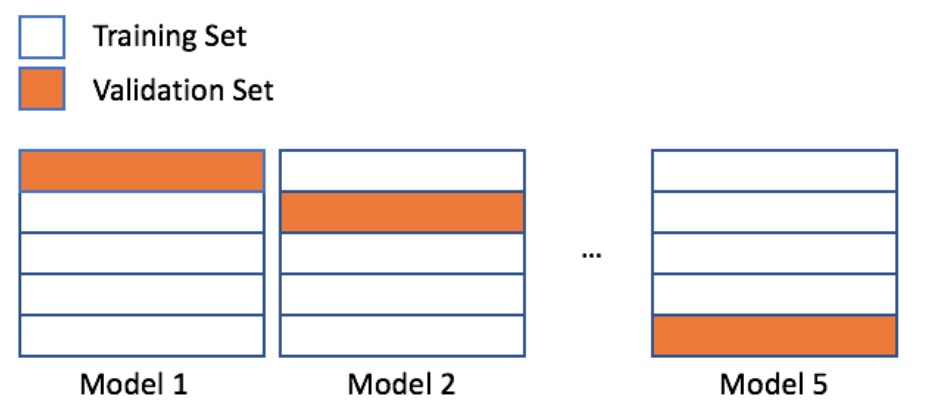

**KFold() do scikit-learn**

Você acabou de executar o código de um colega que cria um modelo de floresta aleatória e calcula a acurácia fora da amostra. Você notou que o código do seu colega não tinha um estado aleatório e os erros que você encontrou foram completamente diferentes dos erros relatados por ele.

Para obter uma estimativa melhor da acurácia desse modelo de floresta aleatória em novos dados, você decidiu gerar alguns índices para usar na validação cruzada KFold.

In [20]:
url = 'https://raw.githubusercontent.com/goodboychan/chans_jupyter/main/_notebooks/dataset/candy-data.csv'
candy = pd.read_csv(url)
candy.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [21]:
X = candy.drop(['competitorname', 'winpercent'], axis=1).to_numpy()
y = candy['winpercent'].to_numpy()

In [28]:
from sklearn.model_selection import KFold

# Uso do KFold
kf = KFold(n_splits=5, shuffle=True, random_state=1111)

# Criando divisões
splits = kf.split(X)

# Print dos indices
for train_index, val_index in splits:
    print("Número de índices de treinamento: %s" % len(train_index))
    print("Número de índices de validação: %s" % len(val_index))

Número de índices de treinamento: 68
Número de índices de validação: 17
Número de índices de treinamento: 68
Número de índices de validação: 17
Número de índices de treinamento: 68
Número de índices de validação: 17
Número de índices de treinamento: 68
Número de índices de validação: 17
Número de índices de treinamento: 68
Número de índices de validação: 17


Este conjunto de dados possui 85 linhas. Você criou cinco divisões, cada uma contendo 68 índices de treinamento e 17 índices de validação. Você pode usar esses índices para realizar uma validação cruzada de 5 partes.

**Usando índices KFold**

Você já criou `divisões`, que contêm índices para o conjunto de dados candy-data para completar a validação cruzada de 5 folds. Para obter uma estimativa melhor do desempenho do modelo de floresta aleatória de um colega em novos dados, você deseja executar esse modelo nos cinco índices de treinamento e validação diferentes que acabou de criar.

Neste exercício, você usará esses índices para verificar a precisão deste modelo usando as cinco `divisões` diferentes. Um loop for foi fornecido para auxiliar nesse processo.

In [23]:
# Criando divisões
splits = kf.split(X)

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rfc = RandomForestRegressor(n_estimators=25, random_state=1111)

# Acesse os índices de treinamento e validação das divisões.
for train_index, val_index in splits:
    # Configuração dos dados de treinamento e validação.
    X_train, y_train = X[train_index], y[train_index]
    X_val, y_val = X[val_index], y[val_index]

    # Ajuste do modelo de random forest
    rfc.fit(X_train, y_train)

    # Faça previsões e print da precisão.
    predictions = rfc.predict(X_val)
    print("Precisão de divisão: " + str(mean_squared_error(y_val, predictions)))

Precisão de divisão: 150.99298148707666
Precisão de divisão: 171.22206240542593
Precisão de divisão: 131.72569156195593
Precisão de divisão: 80.61940183841385
Precisão de divisão: 221.63020627476214


A função `KFold()` é um ótimo método para acessar índices individuais ao realizar validação cruzada. Uma desvantagem, porém, é a necessidade de um loop for para percorrer os índices.

**sklearn's cross_val_score()**

Métodos do scikit-learn

Você decidiu criar um modelo de regressão para prever o número de novos funcionários que sua empresa contratará com sucesso no próximo mês. Você abre um novo script Python para começar, mas logo percebe que o sklearn possui muitos módulos diferentes. Vamos garantir que você entenda os nomes dos módulos, os métodos e qual módulo contém qual método.

Siga as instruções abaixo para carregar todos os métodos necessários para realizar a validação cruzada usando o sklearn. Você usará os módulos:

*   metrics
*   model_selection
*   ensemble






In [25]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, make_scorer

Implemente a função cross_val_score()

Sua empresa criou vários novos doces para vender, mas não tem certeza se deve lançar todos os cinco. Para prever a popularidade desses novos doces, você foi solicitado a construir um modelo de regressão usando o conjunto de dados dos doces. Lembre-se de que o valor da resposta é a porcentagem de vitórias em um confronto direto contra outros doces.

Antes de começar a testar diferentes modelos de regressão, você decidiu executar a validação cruzada em um modelo de floresta aleatória simples para obter um erro de referência para comparar com quaisquer resultados futuros.

In [26]:
rfc = RandomForestRegressor(n_estimators=25, random_state=1111)
mse = make_scorer(mean_squared_error)

# Configuração do cross_val_score
cv = cross_val_score(estimator=rfc, X=X_train, y=y_train, cv=10, scoring=mse)

# Print do erro médio
print(cv.mean())

131.30323056938693


Agora você tem uma pontuação inicial para construir seu modelo. Se decidir criar modelos adicionais ou experimentar novas técnicas, tente obter um erro inferior a 155,56. Erros menores indicam que suas previsões de popularidade estão melhorando.

**Leave-one-out-cross-validation (LOOCV)**

* LOOCV
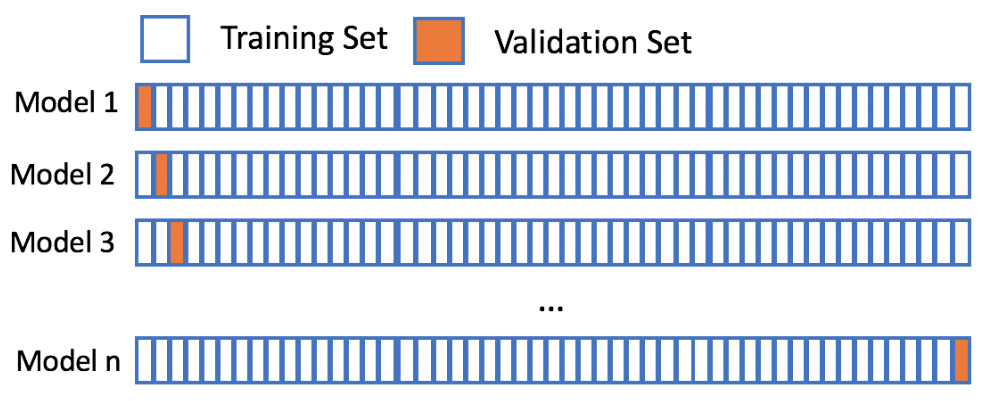

* Quando usar a validação cruzada leave-one-out (LOOCV)?
  * A quantidade de dados de treinamento é limitada
  * Você deseja a melhor estimativa de erro possível para novos dados

* Tenha cautela quando:
  * Os recursos computacionais são limitados
  * Você tem muitos dados
  * Você tem muitos parâmetros para testar

Validação cruzada leave-one-out

Vamos supor que seu doce favorito não esteja no conjunto de dados de doces e que você esteja interessado na popularidade desse doce. Usar a validação cruzada de 5 folds treinará o modelo com apenas 80% dos dados por vez. O conjunto de dados de doces tem apenas 85 linhas, e deixar de fora 20% dos dados poderia prejudicar nosso modelo. No entanto, usar a validação cruzada leave-one-out nos permite aproveitar ao máximo nosso conjunto de dados limitado e fornecerá a melhor estimativa da popularidade do seu doce favorito!

In [27]:
from sklearn.metrics import mean_absolute_error
# Criando um marcador
mae_scorer = make_scorer(mean_absolute_error)

rfr = RandomForestRegressor(n_estimators=15, random_state=1111)

# Implementando o LOOCV
scores = cross_val_score(rfr, X, y, cv=85, scoring=mae_scorer)

# Print a média e o desvio padrão
print("A média dos erros é: %s." % np.mean(scores))
print("O desvio padrão dos erros é: %s." % np.std(scores))

A média dos erros é: 9.52044832324183.
O desvio padrão dos erros é: 7.349020637882744.


Você já percorreu um longo caminho com as técnicas de validação de modelos. O capítulo final concluirá a validação de modelos, discutindo como selecionar o melhor modelo e apresentando uma introdução ao ajuste de parâmetros.